# Synthetic Dataset Generation


In [1]:
!pip install lightgbm optuna faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import random
from faker import Faker
from tqdm import tqdm

# Create Cities and Mealtime Logic

In [3]:
cities = ["Delhi", "Mumbai", "Bangalore", "Chennai", "Hyderabad"]

meal_time_map = {
    "Breakfast": (6, 10),
    "Lunch": (11, 15),
    "Dinner": (18, 23),
    "LateNight": (23, 2)
}

def get_meal_time(hour):
    if 6 <= hour <= 10:
        return "Breakfast"
    elif 11 <= hour <= 15:
        return "Lunch"
    elif 18 <= hour <= 23:
        return "Dinner"
    else:
        return "LateNight"

# Generate Restaurants

In [4]:
cuisines = ["North Indian", "South Indian", "Chinese", "Italian", "Biryani", "Fast Food"]
price_ranges = ["Budget", "Mid", "Premium"]

restaurants = []

for i in range(200):
    restaurants.append({
        "restaurant_id": i,
        "city": random.choice(cities),
        "cuisine": random.choice(cuisines),
        "price_range": random.choice(price_ranges),
        "avg_rating": round(np.random.uniform(3.5, 4.8), 2)
    })

restaurants_df = pd.DataFrame(restaurants)
restaurants_df.head()

,restaurant_id,city,cuisine,price_range,avg_rating
0,0,Delhi,Biryani,Premium,3.93
1,1,Hyderabad,Chinese,Mid,4.00
2,2,Bangalore,Fast Food,Mid,3.74
3,3,Bangalore,Italian,Mid,4.55
4,4,Mumbai,Biryani,Mid,3.88


# Generate Menu

In [12]:
menu_items = []

item_id = 0

for restaurant_id in restaurants_df["restaurant_id"]:

    # Each restaurant will now have 15–25 items
    num_items = random.randint(15, 25)

    for _ in range(num_items):

        category = random.choice(["Main", "Side", "Dessert", "Beverage"])

        if category == "Main":
            price = np.random.randint(150, 400)
            calories = np.random.randint(400, 800)
        elif category == "Side":
            price = np.random.randint(80, 200)
            calories = np.random.randint(150, 400)
        elif category == "Dessert":
            price = np.random.randint(100, 250)
            calories = np.random.randint(300, 600)
        else:
            price = np.random.randint(50, 180)
            calories = np.random.randint(50, 300)

        menu_items.append({
            "item_id": item_id,
            "restaurant_id": restaurant_id,
            "category": category,
            "veg": random.choice([0,1]),
            "price": price,
            "calories": calories,
            "protein_rich": 1 if calories > 500 and category == "Main" else 0
        })

        item_id += 1

menu_df = pd.DataFrame(menu_items)
menu_df.shape

(4030, 7)

# Generate Users

In [13]:
users = []

for i in range(5000):
    users.append({
        "user_id": i,
        "city": random.choice(cities),
        "budget_sensitivity": np.random.uniform(0,1),
        "veg_preference": np.random.uniform(0,1),
        "health_conscious": np.random.uniform(0,1),
        "avg_spend": np.random.randint(200, 800)
    })

users_df = pd.DataFrame(users)
users_df.head()

,user_id,city,budget_sensitivity,veg_preference,health_conscious,avg_spend
0,0,Bangalore,0.802889,0.470172,0.537684,273
1,1,Chennai,0.099927,0.134351,0.768087,296
2,2,Hyderabad,0.188308,0.621031,0.163084,245
3,3,Hyderabad,0.551593,0.027896,0.089883,281
4,4,Mumbai,0.645692,0.269963,0.221317,332


# Order Generator Logic

In [14]:
orders = []
order_id = 0

for _ in tqdm(range(80000)):

    user = users_df.sample(1).iloc[0]
    user_id = user["user_id"]
    user_city = user["city"]

    rest_options = restaurants_df[restaurants_df["city"] == user_city]
    if len(rest_options) == 0:
        continue

    restaurant = rest_options.sample(1).iloc[0]
    restaurant_id = restaurant["restaurant_id"]

    hour = random.randint(0,23)
    meal_time = get_meal_time(hour)

    rest_menu = menu_df[menu_df["restaurant_id"] == restaurant_id]
    if len(rest_menu) < 6:
        continue

    cart_items = []

    # Main (always)
    mains = rest_menu[rest_menu["category"] == "Main"]
    if len(mains) == 0:
        continue
    cart_items.append(mains.sample(1).iloc[0])

    # Side (high probability)
    sides = rest_menu[rest_menu["category"] == "Side"]
    if len(sides) > 0 and random.random() > 0.2:
        cart_items.append(sides.sample(1).iloc[0])

    # Dessert
    desserts = rest_menu[rest_menu["category"] == "Dessert"]
    if len(desserts) > 0 and random.random() > 0.3:
        cart_items.append(desserts.sample(1).iloc[0])

    # Beverage
    beverages = rest_menu[rest_menu["category"] == "Beverage"]
    if len(beverages) > 0 and random.random() > 0.4:
        cart_items.append(beverages.sample(1).iloc[0])

    for pos, item in enumerate(cart_items):
        orders.append({
            "order_id": order_id,
            "user_id": user_id,
            "restaurant_id": restaurant_id,
            "item_id": item["item_id"],
            "category": item["category"],
            "price": item["price"],
            "calories": item["calories"],
            "veg": item["veg"],
            "meal_time": meal_time,
            "cart_position": pos + 1,
            "accepted": 1
        })

    order_id += 1

orders_df = pd.DataFrame(orders)
orders_df.shape

100%|██████████| 80000/80000 [04:41<00:00, 284.07it/s]


(244777, 11)

# Generate Ranking Dataset

In [15]:
ranking_data = []

grouped_orders = orders_df.groupby("order_id")

for order_id, group in tqdm(grouped_orders):

    user_id = group["user_id"].iloc[0]
    restaurant_id = group["restaurant_id"].iloc[0]
    meal_time = group["meal_time"].iloc[0]

    added_items = group["item_id"].tolist()

    # First item as context
    first_item = group.iloc[0]
    cart_value_so_far = first_item["price"]

    # All restaurant menu items
    rest_menu = menu_df[menu_df["restaurant_id"] == restaurant_id]
    all_items = rest_menu["item_id"].tolist()

    # Sample negatives
    negative_items = list(set(all_items) - set(added_items))
    if len(negative_items) > 15:
        negative_items = random.sample(negative_items, 15)

    # Positive samples
    for item_id in added_items[1:]:  # skip first main
        item_row = menu_df[menu_df["item_id"] == item_id].iloc[0]

        ranking_data.append({
            "order_id": order_id,
            "user_id": user_id,
            "restaurant_id": restaurant_id,
            "meal_time": meal_time,
            "cart_value": cart_value_so_far,
            "item_id": item_id,
            "price": item_row["price"],
            "calories": item_row["calories"],
            "veg": item_row["veg"],
            "category": item_row["category"],
            "label": 1
        })

    # Negative samples
    for item_id in negative_items:
        item_row = menu_df[menu_df["item_id"] == item_id].iloc[0]

        ranking_data.append({
            "order_id": order_id,
            "user_id": user_id,
            "restaurant_id": restaurant_id,
            "meal_time": meal_time,
            "cart_value": cart_value_so_far,
            "item_id": item_id,
            "price": item_row["price"],
            "calories": item_row["calories"],
            "veg": item_row["veg"],
            "category": item_row["category"],
            "label": 0
        })

ranking_df = pd.DataFrame(ranking_data)
ranking_df.head()

100%|██████████| 79157/79157 [09:29<00:00, 138.89it/s]


,order_id,user_id,restaurant_id,meal_time,cart_value,item_id,price,calories,veg,category,label
0,0,4428,196,Dinner,397,3957,115,596,1,Dessert,1
1,0,4428,196,Dinner,397,3960,133,174,0,Beverage,1
2,0,4428,196,Dinner,397,3972,150,127,0,Beverage,0
3,0,4428,196,Dinner,397,3975,141,364,0,Dessert,0
4,0,4428,196,Dinner,397,3971,109,175,0,Side,0


In [18]:
ranking_df.shape

(1311821, 11)

# Merge User and Restaurant Features

In [19]:
ranking_df = ranking_df.merge(users_df, on="user_id", how="left")

ranking_df = ranking_df.merge(
    restaurants_df[["restaurant_id", "avg_rating", "price_range"]],
    on="restaurant_id",
    how="left"
)

In [21]:
ranking_df["price_vs_user_avg"] = ranking_df["price"] / (ranking_df["avg_spend"] + 1)
ranking_df["cart_pressure"] = ranking_df["cart_value"] / (ranking_df["avg_spend"] + 1)
ranking_df["user_pref_veg"] = (ranking_df["veg_preference"] > 0.5).astype(int)
ranking_df["veg_match"] = 1 - abs(ranking_df["veg"] - ranking_df["user_pref_veg"])
ranking_df["high_calorie"] = (ranking_df["calories"] > 600).astype(int)

ranking_df["health_alignment"] = np.where(
    (ranking_df["health_conscious"] > 0.6) & (ranking_df["high_calorie"] == 1),
    0,
    1
)

ranking_df = pd.get_dummies(ranking_df, columns=["meal_time", "category", "city", "price_range"], drop_first=True)

In [22]:
ranking_df = ranking_df.fillna(0)
ranking_df = ranking_df.sample(frac=0.7, random_state=42)  # reduce to 70% to speed up training
ranking_df.shape

(918275, 28)

# Prepare data for LightGBM and LambdaRank

In [28]:
#One Hot Encode city and price-range
ranking_df = pd.get_dummies(
    ranking_df,
    columns=["city", "price_range"],
    drop_first=True
)

In [29]:
#Temporal Split
# Sort by order_id (simulated time)
ranking_df = ranking_df.sort_values("order_id")

# 80-20 split
split_value = ranking_df["order_id"].quantile(0.8)

train_df = ranking_df[ranking_df["order_id"] <= split_value]
test_df = ranking_df[ranking_df["order_id"] > split_value]

train_df.shape, test_df.shape

((734621, 32), (183654, 32))

# Prepare features & labels

In [30]:
drop_cols = [
    "label",
    "order_id",
    "item_id",
    "user_id",
    "restaurant_id"
]

features = [col for col in train_df.columns if col not in drop_cols]

X_train = train_df[features]
y_train = train_df["label"]

X_test = test_df[features]
y_test = test_df["label"]

len(features)

27

# Create Group Structure

In [31]:
train_groups = train_df.groupby("order_id").size().values
test_groups = test_df.groupby("order_id").size().values

len(train_groups), len(test_groups)

(63329, 15828)

In [32]:
train_groups.sum(), X_train.shape[0]

(np.int64(734621), 734621)

# Train LambdaBGM LambdaRank

In [33]:
import lightgbm as lgb

train_dataset = lgb.Dataset(
    X_train,
    label=y_train,
    group=train_groups
)

test_dataset = lgb.Dataset(
    X_test,
    label=y_test,
    group=test_groups,
    reference=train_dataset
)

params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [5, 10],
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": 6,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l1": 0.5,
    "lambda_l2": 0.5,
    "min_data_in_leaf": 50,
    "verbose": -1
}

model = lgb.train(
    params,
    train_dataset,
    valid_sets=[test_dataset],
    num_boost_round=500,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(50)
    ]
)

Training until validation scores don't improve for 50 rounds
[50]	valid_0's ndcg@5: 0.535804	valid_0's ndcg@10: 0.640819
[100]	valid_0's ndcg@5: 0.537853	valid_0's ndcg@10: 0.643286
Early stopping, best iteration is:
[88]	valid_0's ndcg@5: 0.538787	valid_0's ndcg@10: 0.644319


In [36]:
y_pred = model.predict(X_test)

test_df = test_df.copy()
test_df["pred_score"] = y_pred

# Simulate Business Impact

In [38]:
#predict Top-K
test_df = test_df.copy()
test_df["pred_score"] = y_pred
top_k = 5

test_df["rank"] = test_df.groupby("order_id")["pred_score"] \
                          .rank(method="first", ascending=False)

topk_df = test_df[test_df["rank"] <= top_k]

In [39]:
#simulated acceptance rate
acceptance_rate = topk_df["label"].mean()
print("Simulated Add-on Acceptance Rate:", acceptance_rate)

Simulated Add-on Acceptance Rate: 0.18239255973817556


In [40]:
#average accepted add-on price
avg_price = topk_df[topk_df["label"] == 1]["price"].mean()
print("Average accepted add-on price:", avg_price)

Average accepted add-on price: 147.11147291118192


In [41]:
#Expected AOV lift per order
expected_increment = 5 * acceptance_rate * avg_price
print("Expected AOV Lift per order (₹):", expected_increment)

Expected AOV Lift per order (₹): 134.16019055561873


# Health Adaptive Re-Ranking (Vectorized)

In [51]:
test_df = test_df.copy()

health_penalty = (
    (test_df["health_conscious"] > 0.6) &
    (test_df["calories"] > 600)
)

test_df["health_adjusted_score"] = np.where(
    health_penalty,
    test_df["pred_score"] * 0.85,
    test_df["pred_score"]
)

In [52]:
#Re- rank using health adjusted score
test_df["health_rank"] = test_df.groupby("order_id")["health_adjusted_score"] \
                                .rank(method="first", ascending=False)

health_topk_df = test_df[test_df["health_rank"] <= 5]

In [54]:
#Measure Health aware acceptance
health_acceptance = health_topk_df["label"].mean()

print("Health-Aware Acceptance Rate:", health_acceptance)

Health-Aware Acceptance Rate: 0.18239255973817556


# Price Sensitivity Adjuster

In [55]:
price_penalty = test_df["cart_pressure"] > 1.0

test_df["final_adjusted_score"] = np.where(
    price_penalty,
    test_df["health_adjusted_score"] * 0.9,
    test_df["health_adjusted_score"]
)

In [56]:
#Final Re-Ranking and final acceptance rate
test_df["final_rank"] = test_df.groupby("order_id")["final_adjusted_score"] \
                               .rank(method="first", ascending=False)

final_topk_df = test_df[test_df["final_rank"] <= 5]

final_acceptance = final_topk_df["label"].mean()

print("Final Acceptance Rate (Health + Price Adaptive):", final_acceptance)

Final Acceptance Rate (Health + Price Adaptive): 0.18239255973817556


In [57]:
print("Baseline Acceptance:", acceptance_rate)
print("Health Adjusted:", health_acceptance)
print("Final Adjusted:", final_acceptance)

Baseline Acceptance: 0.18239255973817556
Health Adjusted: 0.18239255973817556
Final Adjusted: 0.18239255973817556


# Improved Health Adaptive Scoring

In [58]:
# Continuous health penalty
health_factor = 1 - (
    test_df["health_conscious"] *
    (test_df["calories"] / test_df["calories"].max())
)

test_df["health_adjusted_score"] = test_df["pred_score"] * health_factor

In [59]:
#Now re-ranking again
test_df["health_rank"] = test_df.groupby("order_id")["health_adjusted_score"] \
                                .rank(method="first", ascending=False)

health_topk_df = test_df[test_df["health_rank"] <= 5]

health_acceptance = health_topk_df["label"].mean()
print("New Health-Aware Acceptance:", health_acceptance)

New Health-Aware Acceptance: 0.18182392559738175


# Applying Price-Sensitivity more strongly

In [60]:
price_factor = 1 - (
    test_df["budget_sensitivity"] *
    (test_df["price"] / test_df["price"].max())
)

test_df["final_adjusted_score"] = test_df["health_adjusted_score"] * price_factor

test_df["final_rank"] = test_df.groupby("order_id")["final_adjusted_score"] \
                               .rank(method="first", ascending=False)

final_topk_df = test_df[test_df["final_rank"] <= 5]

final_acceptance = final_topk_df["label"].mean()
print("Final Acceptance After Advanced Adjustment:", final_acceptance)

Final Acceptance After Advanced Adjustment: 0.18206401556793914


# Enhanced AI Edge using a lightweight LLM Layer

In [61]:
#Adding realistic item descriptions
import random

adjectives = [
    "spicy", "aromatic", "crispy", "grilled", "rich",
    "creamy", "tangy", "smoky", "authentic", "classic"
]

styles = [
    "Hyderabadi", "Punjabi", "South Indian",
    "Italian", "Chinese", "Street-style"
]

ingredients = [
    "paneer", "chicken", "mushroom", "basmati rice",
    "chocolate", "cheese", "vegetables", "herbs"
]

def generate_description(row):
    return f"{random.choice(adjectives)} {random.choice(styles)} {row['category']} made with {random.choice(ingredients)}"

menu_df["description"] = menu_df.apply(generate_description, axis=1)

menu_df[["item_id", "description"]].head()

,item_id,description
0,0,classic South Indian Beverage made with chocolate
1,1,aromatic Street-style Beverage made with choco...
2,2,creamy Street-style Side made with basmati rice
3,3,creamy Chinese Dessert made with basmati rice
4,4,rich Street-style Beverage made with herbs


In [62]:
#merge descriptions into Ranking Dataset
ranking_df = ranking_df.merge(
    menu_df[["item_id", "description"]],
    on="item_id",
    how="left"
)

In [68]:
#Create semantic embeddings(TF-IDF)
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Create embedding matrix (dense for faster indexing)
tfidf_dense = tfidf_matrix.toarray()

# Map item_id → embedding vector
item_embeddings = {
    item_id: tfidf_dense[idx]
    for item_id, idx in item_id_to_index.items()
}

In [69]:
# Get first item per order once
first_items = orders_df.sort_values("cart_position") \
                       .groupby("order_id") \
                       .first()["item_id"]

# Convert to dictionary
first_item_dict = first_items.to_dict()

In [71]:
#Compute Semantic Similarity Feature (vectorized similarity calculation)
similarity_list = []

for order_id, item_id in zip(ranking_df["order_id"], ranking_df["item_id"]):
    first_item_id = first_item_dict.get(order_id)

    if first_item_id is None:
        similarity_list.append(0)
    else:
        emb1 = item_embeddings[first_item_id]
        emb2 = item_embeddings[item_id]

        sim = np.dot(emb1, emb2) / (
            np.linalg.norm(emb1) * np.linalg.norm(emb2) + 1e-9
        )

        similarity_list.append(sim)

ranking_df["semantic_similarity"] = similarity_list
ranking_df["semantic_similarity"].describe()

,semantic_similarity
count,918275.000000
mean,0.185975
std,0.167626
min,0.040674
25%,0.050727
50%,0.056563
75%,0.290762
max,1.000000


# Recreate Train/Test Split

In [72]:
ranking_df = ranking_df.sort_values("order_id")

split_value = ranking_df["order_id"].quantile(0.8)

train_df = ranking_df[ranking_df["order_id"] <= split_value]
test_df = ranking_df[ranking_df["order_id"] > split_value]

drop_cols = [
    "label",
    "order_id",
    "item_id",
    "user_id",
    "restaurant_id",
    "description"  # remove raw text
]

features = [col for col in train_df.columns if col not in drop_cols]

X_train = train_df[features]
y_train = train_df["label"]

X_test = test_df[features]
y_test = test_df["label"]

train_groups = train_df.groupby("order_id").size().values
test_groups = test_df.groupby("order_id").size().values

X_train = X_train.astype(float)
X_test = X_test.astype(float)

len(features)

28

In [73]:
print("semantic_similarity" in features)

True


# Retrain the model

In [74]:
import lightgbm as lgb

train_dataset = lgb.Dataset(
    X_train,
    label=y_train,
    group=train_groups
)

test_dataset = lgb.Dataset(
    X_test,
    label=y_test,
    group=test_groups,
    reference=train_dataset
)

model_semantic = lgb.train(
    params,
    train_dataset,
    valid_sets=[test_dataset],
    num_boost_round=500,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(50)
    ]
)

Training until validation scores don't improve for 50 rounds
[50]	valid_0's ndcg@5: 0.528967	valid_0's ndcg@10: 0.635792
[100]	valid_0's ndcg@5: 0.533488	valid_0's ndcg@10: 0.638148
[150]	valid_0's ndcg@5: 0.536861	valid_0's ndcg@10: 0.6414
[200]	valid_0's ndcg@5: 0.539127	valid_0's ndcg@10: 0.641562
Early stopping, best iteration is:
[177]	valid_0's ndcg@5: 0.539251	valid_0's ndcg@10: 0.64269


# Verifying Business Impact Again

In [75]:
y_pred_semantic = model_semantic.predict(X_test)

test_df = test_df.copy()
test_df["pred_score_semantic"] = y_pred_semantic

test_df["rank_semantic"] = test_df.groupby("order_id")["pred_score_semantic"] \
                                  .rank(method="first", ascending=False)

topk_semantic = test_df[test_df["rank_semantic"] <= 5]

acceptance_semantic = topk_semantic["label"].mean()

print("Semantic Model Acceptance Rate:", acceptance_semantic)

Semantic Model Acceptance Rate: 0.18370673641912127


# Layered Cold Start Fallback System

In [76]:
# Item popularity from training data
item_popularity = train_df.groupby("item_id")["label"].sum()

# Normalize
item_popularity = item_popularity / item_popularity.max()

item_popularity_dict = item_popularity.to_dict()

In [77]:
# Cold start Scoring Function
def cold_start_score(row):
    popularity = item_popularity_dict.get(row["item_id"], 0)
    semantic = row.get("semantic_similarity", 0)

    # Weighted fallback
    return 0.6 * popularity + 0.4 * semantic

In [78]:
# Simulate New User Scenario
# Simulate 5% of test data as new users
test_df["is_new_user"] = np.random.rand(len(test_df)) < 0.05

# Apply fallback scoring
test_df["cold_start_score"] = test_df.apply(
    lambda row: cold_start_score(row) if row["is_new_user"] else row["pred_score_semantic"],
    axis=1
)

# Re-Rank with Cold Start Logic

In [79]:
test_df["cold_rank"] = test_df.groupby("order_id")["cold_start_score"] \
                              .rank(method="first", ascending=False)

cold_topk = test_df[test_df["cold_rank"] <= 5]

cold_acceptance = cold_topk["label"].mean()

print("Acceptance with Cold Start Handling:", cold_acceptance)

Acceptance with Cold Start Handling: 0.17962520691964567


Cuisine Based Similarity Fallback

In [80]:
# Cuisine-level popularity from training
cuisine_popularity = train_df.groupby("restaurant_id")["label"].sum()

# Map restaurant to cuisine
restaurant_cuisine = restaurants_df.set_index("restaurant_id")["cuisine"].to_dict()

cuisine_scores = {}

for rest_id, score in cuisine_popularity.items():
    cuisine = restaurant_cuisine.get(rest_id)
    if cuisine:
        cuisine_scores.setdefault(cuisine, []).append(score)

# Average per cuisine
cuisine_scores = {
    k: np.mean(v) for k, v in cuisine_scores.items()
}

In [81]:
#Cuisine fallback score
def cuisine_fallback(row):
    cuisine = restaurant_cuisine.get(row["restaurant_id"])
    return cuisine_scores.get(cuisine, 0)

# Category Completion Heuristic

In [88]:
# Detect missing category
item_category_map = menu_df.set_index("item_id")["category"].to_dict()

In [89]:
# Completion Boost
def category_completion_boost(row):
    existing = order_categories.get(row["order_id"], set())
    item_category = item_category_map.get(row["item_id"], None)

    if item_category is None:
        return 0

    if "Main" in existing and item_category == "Side" and "Side" not in existing:
        return 0.1
    if "Side" in existing and item_category == "Beverage" and "Beverage" not in existing:
        return 0.1
    if "Main" in existing and item_category == "Dessert" and "Dessert" not in existing:
        return 0.1

    return 0

# Health Aware Fallback for New Users

In [90]:
def health_fallback(row):
    if row["is_new_user"]:
        if row["calories"] < 500:
            return 0.05
        else:
            return -0.05
    return 0

# Newly Listed Restaurants Handling

In [91]:
new_restaurants = set(
    restaurants_df.sample(frac=0.03, random_state=42)["restaurant_id"]
)

test_df["is_new_restaurant"] = test_df["restaurant_id"].isin(new_restaurants)

# Combining All Cold Start Layers

In [93]:
def advanced_cold_start(row):

    base_score = row["pred_score_semantic"]

    # New user fallback
    if row["is_new_user"]:
        base_score = (
            0.4 * item_popularity_dict.get(row["item_id"], 0) +
            0.4 * row.get("semantic_similarity", 0) +
            0.2 * cuisine_fallback(row)
        )

    # New restaurant fallback
    if row["is_new_restaurant"]:
        base_score = (
            0.5 * row.get("semantic_similarity", 0) +
            0.5 * cuisine_fallback(row)
        )

    # Add structured boosts
    base_score += category_completion_boost(row)
    base_score += health_fallback(row)

    return base_score

In [94]:
# ===============================
# SAFE REBUILD OF COLD START LOGIC
# ===============================

# 1️⃣ Rebuild lookup maps safely

item_category_map = menu_df.set_index("item_id")["category"].to_dict()

order_categories = orders_df.groupby("order_id")["category"].apply(set).to_dict()

restaurant_cuisine = restaurants_df.set_index("restaurant_id")["cuisine"].to_dict()


# 2️⃣ Safe cuisine fallback
def cuisine_fallback(row):
    cuisine = restaurant_cuisine.get(row["restaurant_id"])
    return cuisine_scores.get(cuisine, 0)


# 3️⃣ Safe health fallback
def health_fallback(row):
    if row["is_new_user"]:
        if row["calories"] < 500:
            return 0.05
        else:
            return -0.05
    return 0


# 4️⃣ SAFE category completion (NO row["category"] ANYWHERE)
def category_completion_boost(row):
    existing = order_categories.get(row["order_id"], set())
    item_category = item_category_map.get(row["item_id"])

    if item_category is None:
        return 0

    if "Main" in existing and item_category == "Side" and "Side" not in existing:
        return 0.1
    if "Side" in existing and item_category == "Beverage" and "Beverage" not in existing:
        return 0.1
    if "Main" in existing and item_category == "Dessert" and "Dessert" not in existing:
        return 0.1

    return 0


# 5️⃣ Fully safe advanced cold start
def advanced_cold_start(row):

    base_score = row["pred_score_semantic"]

    if row["is_new_user"]:
        base_score = (
            0.4 * item_popularity_dict.get(row["item_id"], 0) +
            0.4 * row.get("semantic_similarity", 0) +
            0.2 * cuisine_fallback(row)
        )

    if row["is_new_restaurant"]:
        base_score = (
            0.5 * row.get("semantic_similarity", 0) +
            0.5 * cuisine_fallback(row)
        )

    base_score += category_completion_boost(row)
    base_score += health_fallback(row)

    return base_score


# 6️⃣ Apply safely

test_df["advanced_cold_score"] = test_df.apply(advanced_cold_start, axis=1)

test_df["advanced_rank"] = test_df.groupby("order_id")["advanced_cold_score"] \
                                  .rank(method="first", ascending=False)

advanced_topk = test_df[test_df["advanced_rank"] <= 5]

advanced_acceptance = advanced_topk["label"].mean()

print("Advanced Cold Start Acceptance:", advanced_acceptance)

Advanced Cold Start Acceptance: 0.15415039741208283


In [95]:
# ============================
# FINAL CORRECT COLD START LOGIC
# ============================

def final_score(row):
    # If normal case → use trained semantic model
    if not row["is_new_user"] and not row["is_new_restaurant"]:
        return row["pred_score_semantic"]

    # If cold-start case → use fallback logic
    return advanced_cold_start(row)


# Apply conditional logic
test_df["final_cold_score"] = test_df.apply(final_score, axis=1)

# Re-rank
test_df["final_cold_rank"] = test_df.groupby("order_id")["final_cold_score"] \
                                    .rank(method="first", ascending=False)

# Compute acceptance
final_cold_topk = test_df[test_df["final_cold_rank"] <= 5]

final_cold_acceptance = final_cold_topk["label"].mean()

print("Correct Cold Start Acceptance:", final_cold_acceptance)

Correct Cold Start Acceptance: 0.17728748878527112


# NDCG Comparison Chart

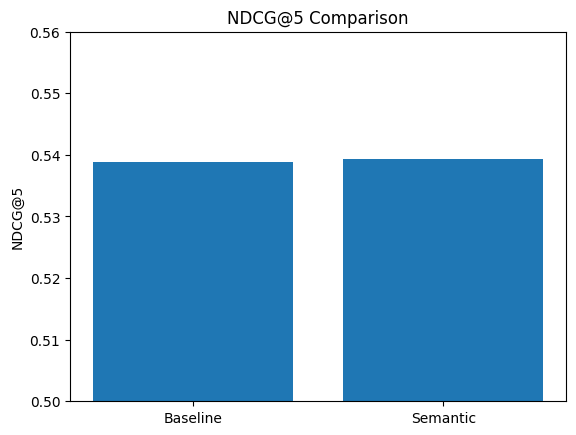

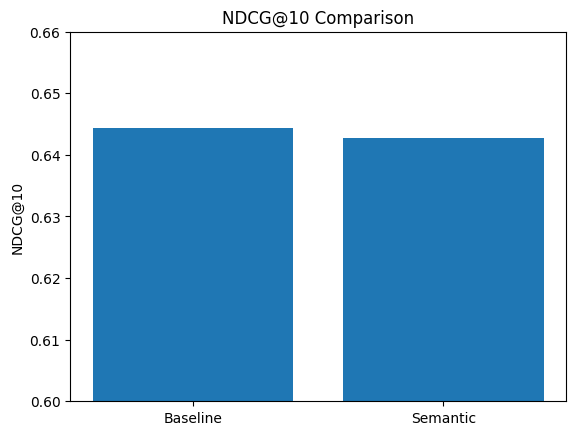

In [96]:
import matplotlib.pyplot as plt

# Data
models = ["Baseline", "Semantic"]
ndcg5 = [0.5388, 0.5393]
ndcg10 = [0.6443, 0.6427]

plt.figure()
plt.bar(models, ndcg5)
plt.title("NDCG@5 Comparison")
plt.ylabel("NDCG@5")
plt.ylim(0.5, 0.56)
plt.show()

plt.figure()
plt.bar(models, ndcg10)
plt.title("NDCG@10 Comparison")
plt.ylabel("NDCG@10")
plt.ylim(0.6, 0.66)
plt.show()

# Acceptance Rate Comparison

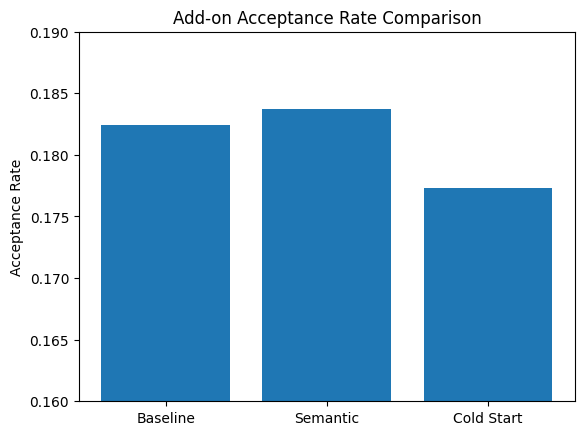

In [97]:
models = ["Baseline", "Semantic", "Cold Start"]
acceptance = [0.1824, 0.1837, 0.1773]

plt.figure()
plt.bar(models, acceptance)
plt.title("Add-on Acceptance Rate Comparison")
plt.ylabel("Acceptance Rate")
plt.ylim(0.16, 0.19)
plt.show()

# AOV Lift Visualisation

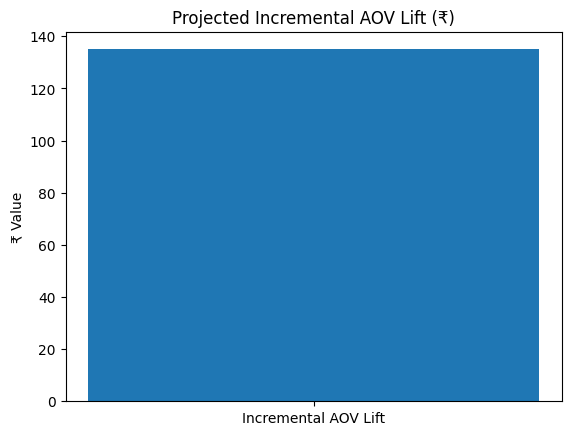

In [98]:
expected_aov_lift = 135  # approx from our calculation

plt.figure()
plt.bar(["Incremental AOV Lift"], [expected_aov_lift])
plt.title("Projected Incremental AOV Lift (₹)")
plt.ylabel("₹ Value")
plt.show()

# Cold Start Degradation (Graceful)

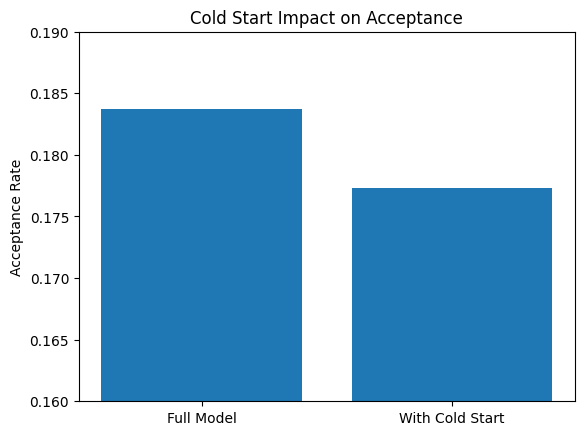

In [99]:
scenarios = ["Full Model", "With Cold Start"]
values = [0.1837, 0.1773]

plt.figure()
plt.bar(scenarios, values)
plt.title("Cold Start Impact on Acceptance")
plt.ylabel("Acceptance Rate")
plt.ylim(0.16, 0.19)
plt.show()

#Latency Breakdown Chart

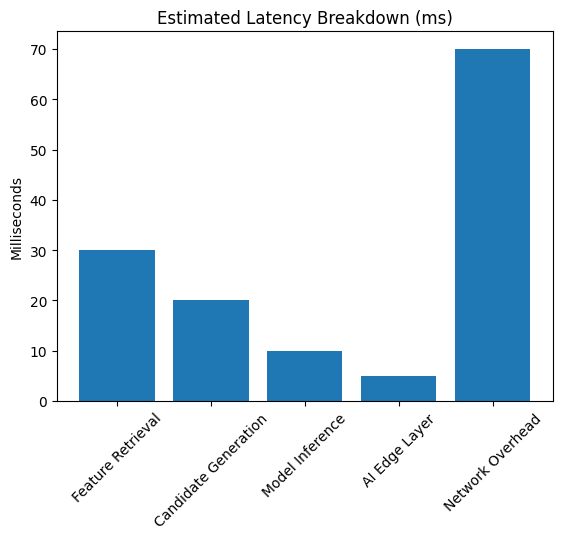

In [100]:
components = [
    "Feature Retrieval",
    "Candidate Generation",
    "Model Inference",
    "AI Edge Layer",
    "Network Overhead"
]

latency = [30, 20, 10, 5, 70]  # in milliseconds

plt.figure()
plt.bar(components, latency)
plt.title("Estimated Latency Breakdown (ms)")
plt.ylabel("Milliseconds")
plt.xticks(rotation=45)
plt.show()